# Section 2: System Identification
Qualitative tests for the Fading Memory Property (FMP), Echo State Property (ESP),
and Separation Property (SP). Visual fingerprinting via Lissajous Plot series.
Observational orthogonality is reported alongside every test.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import json, os
from prc_toolkit.config import FS, DT, V_MAX, RESULTS_DIR
from prc_toolkit.dut.base import to_input_seq
from prc_toolkit.dut.factory import make_dut, prepare_input
from prc_toolkit.dut.ag2s_nwn import RECOMMENDED_PARAMS   # for switching to Ag2S-NWN
from prc_toolkit.signals.generators import (
    sine_sweep, dc_near_zero,
    poisson_spike_train, delayed_spike_train
)
from prc_toolkit.analysis.lissajous import (
    lissajous_response, lissajous_io, lissajous_residual,
    lissajous_state, fingerprint_grid
)
from prc_toolkit.analysis.orthogonality import observational_orthogonality
from prc_toolkit.utils.settling import run_until_settled

In [2]:
# ── Load V_safe from Section 1 ─────────────────────────
with open(os.path.join(RESULTS_DIR, "section1_results.json")) as f:
    s1 = json.load(f)

V_SAFE     = s1["V_SAFE"]
DUT_PARAMS = s1["DUT_params"]  # for Ag2S-NWN, use RECOMMENDED_PARAMS instead (see prc_toolkit.dut.ag2s_nwn)
# DUT_PARAMS = RECOMMENDED_PARAMS  # Uncomment to switch to Ag2S-NWN

print(f"Loaded V_safe = {V_SAFE:.3f} from Section 1 results.")

# ── DUT selection: "liesn" (default), "ag2s_nwn", or "hardware" ─────────
DUT_MODEL = "liesn"
# DUT_MODEL = "ag2s_nwn"
# DUT_MODEL = "hardware"

# True whenever DUT_MODEL == "hardware" -- suppresses simulation-only
# outputs (e.g. Column D of the visual fingerprint, unavailable on real
# hardware).
HARDWARE_MODE = (DUT_MODEL == "hardware")

# Pre-recorded output CSVs are loaded from here when DUT_MODEL == "hardware".
# Defaults to the committed demo dataset so hardware mode works without real
# hardware attached; point this at data/hardware/outputs once you've recorded
# real data via 00_hardware_signals.ipynb.
HARDWARE_DATA_PATH = "data/demo/hardware_outputs"

# Set True (with DUT_MODEL="liesn") to regenerate data/demo/hardware_outputs/,
# then set back to False.
SAVE_DEMO_HARDWARE_DATA = False

# ── Section 2 test parameters ──────────────────────────
N_AMP_STEPS_FP     = 10    # Amplitude steps for the visual fingerprint sweep
FP_SETTLE_PERIODS = 2      # Sine periods driven but discarded (let the transient settle)
FP_RECORD_PERIODS = 3      # Sine periods recorded after settling

N_TRIALS = 2   # hardcoded — the FMP/ESP test is designed for exactly 2 trials

SETTLE_DURATION   = 10.0   # Seconds of settling input for FMP/ESP test
PROBE_DURATION    = 10.0   # Seconds of near-zero DC probe after settling (FMP test)
ESP_SWAP_DURATION = 10.0   # Seconds of u_C input for ESP observation

POISSON_RATE_HZ   = 5.0    # Average spike rate for separation property test
SPIKE_DURATION    = 15.0   # Total duration of spike train (seconds)
PULSE_WIDTH       = 2      # Spike pulse width in samples
SPIKE_IDX         = int(2.0 * FS)  # Index of the spike to delay (2 seconds in)
DELAY_SAMPLES     = int(0.1 * FS)  # Delay displacement in samples (100 ms)
SEED_SPIKES       = 7

Loaded V_safe = 0.800 from Section 1 results.


In [3]:
assert DUT_MODEL in ("liesn", "ag2s_nwn", "hardware"), (
    f"DUT_MODEL '{DUT_MODEL}' is not supported in this notebook. "
    f"Supported values: 'liesn', 'ag2s_nwn', 'hardware'."
)

# ── Instantiate DUT ─────────────────────────────────────
dut = make_dut(DUT_MODEL, DUT_PARAMS)

In [4]:
# ── Hardware I/O helpers ─────────────────────────────────
# Plain stdlib csv module, not pandas -- this toolkit has no pandas
# dependency (see 04_benchmarks.ipynb's sunspot loader for precedent).
import csv
from pathlib import Path

def load_hardware_output(filename: str) -> np.ndarray:
    """
    Load a pre-recorded hardware output CSV from HARDWARE_DATA_PATH.

    Expected format:
      - Header row with column names h0, h1, h2, ... (one per output electrode)
      - One row per timestep
      - Values are floating-point voltage readings

    Returns H: array, shape (T, N_h).

    If the file is not found, raises FileNotFoundError with a helpful message
    directing the operator to 00_hardware_signals.ipynb for recording instructions.
    """
    path = Path(HARDWARE_DATA_PATH) / filename
    if not path.exists():
        raise FileNotFoundError(
            f"Hardware output file not found: {path}\n"
            f"Run 00_hardware_signals.ipynb and follow the recording instructions "
            f"to generate this file before running this notebook."
        )
    with open(path, newline="") as f:
        reader = csv.reader(f)
        next(reader)  # header row (h0, h1, ...)
        rows = [[float(v) for v in row] for row in reader]
    return np.array(rows, dtype=float)


DEMO_DATA_PATH = Path("data/demo/hardware_outputs")

def save_hardware_demo(filename: str, H: np.ndarray):
    """
    Save H into the committed demo dataset (data/demo/hardware_outputs/) so
    that DUT_MODEL="hardware" works out of the box without real hardware.
    No-op unless SAVE_DEMO_HARDWARE_DATA = False. Regenerate the demo dataset
    by re-running this notebook with DUT_MODEL="liesn" and
    SAVE_DEMO_HARDWARE_DATA=True.
    """
    if not SAVE_DEMO_HARDWARE_DATA:
        return
    DEMO_DATA_PATH.mkdir(parents=True, exist_ok=True)
    header = [f"h{i}" for i in range(H.shape[1])]
    with open(DEMO_DATA_PATH / filename, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(header)
        writer.writerows(H.tolist())


## 2.1 Visual Fingerprint via Lissajous Plot Series

A pure sine is applied at N_AMP_STEPS amplitude levels, evenly spaced in dB from
-20 dB to 0 dB relative to V_safe. The four Lissajous Plot types are rendered overlaid,
colored by input amplitude (purple = quiet, yellow = loud).

**I/O convention for this test:**
- u(t): scalar input, shape (T,)
- h(t): scalar output = ‖h‖₂, shape (T,). Used in LP types A, B, C.
- Wx(t): scalar = ‖W·x‖₂, shape (T,). Used in LP type D (simulation only).
- Orthogonality: computed from full electrode vector H, shape (T, N_h).

Column D (State LP) is only available in simulation. For hardware DUTs, pass
`Wx_scalar=None` and that column will be omitted from the grid.

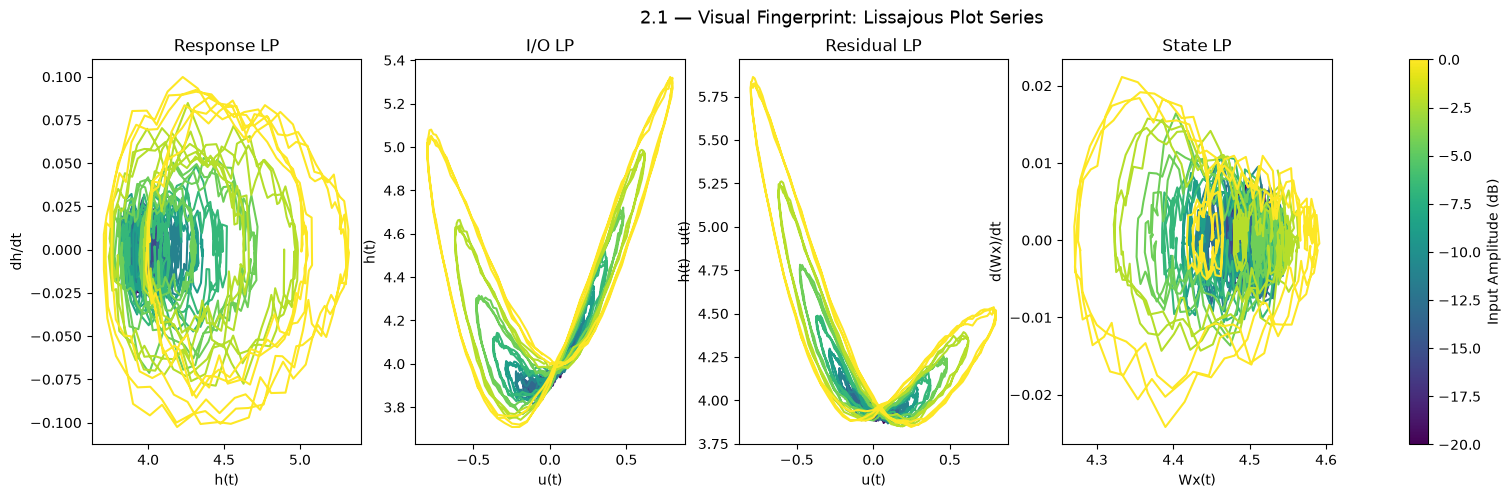

Observational orthogonality (mean across sweep): 0.2824
(0 = redundant electrodes, 1 = maximally independent)


In [5]:
# ── 2.1 Visual Fingerprint ─────────────────────────────
# Sine period = 1s (1 Hz). Each amplitude step drives the DUT for
# FP_SETTLE_PERIODS periods (discarded) then FP_RECORD_PERIODS periods
# (recorded) -- avoids the long transient tail that makes the LPs hard to read.
FP_DURATION = float(FP_SETTLE_PERIODS + FP_RECORD_PERIODS)
N_SETTLE_FP = int(FP_SETTLE_PERIODS * FS)

sweep = sine_sweep(
    duration=FP_DURATION,
    amplitude=V_SAFE,
    n_steps=N_AMP_STEPS_FP,
    fs=FS
)

sweep_results = []
ortho_fp_list = []

for amp_idx, (amp_linear, u_step) in enumerate(sweep):
    amp_dB = 20 * np.log10(amp_linear / V_SAFE)
    u_step = prepare_input(u_step, V_SAFE, DUT_MODEL)

    # --- Data collection: settle for FP_SETTLE_PERIODS, record the rest ---
    if DUT_MODEL == "hardware":
        H_step = load_hardware_output(f"section2_fingerprint_amp{amp_idx:02d}.csv")
        Wx_scalar = None   # Column D not available for hardware
    elif DUT_MODEL == "liesn":
        # Manual step loop (equivalent to dut.run()) to also capture hidden
        # state x for Column D: Wx_scalar = ||W @ x||.
        dut.reset()
        u_seq = to_input_seq(u_step)
        H_full  = np.empty((u_seq.shape[0], dut.N_h))
        Wx_full = np.empty(u_seq.shape[0])
        for t in range(u_seq.shape[0]):
            H_full[t]  = dut.step(u_seq[t])
            Wx_full[t] = np.linalg.norm(dut.W @ dut.x)
        H_step    = H_full[N_SETTLE_FP:]
        Wx_scalar = Wx_full[N_SETTLE_FP:]
        save_hardware_demo(f"section2_fingerprint_amp{amp_idx:02d}.csv", H_step)
    else:  # DUT_MODEL == "ag2s_nwn"
        # Manual step loop to also capture Column D. Ag2S-NWN's persistent
        # memory is the bridge-length matrix L -- V is re-solved from scratch
        # each step from L (via G) and u, so it carries no memory of its own
        # (see Ag2SNWN.reset()'s docstring). L is the analog of LI-ESN's x:
        # Wx_scalar = ||L||_F.
        dut.reset()
        u_seq = to_input_seq(u_step)
        H_full  = np.empty((u_seq.shape[0], dut.N_out))
        Wx_full = np.empty(u_seq.shape[0])
        for t in range(u_seq.shape[0]):
            H_full[t]  = dut.step(u_seq[t])
            Wx_full[t] = np.linalg.norm(dut.L)
        H_step    = H_full[N_SETTLE_FP:]
        Wx_scalar = Wx_full[N_SETTLE_FP:]
        save_hardware_demo(f"section2_fingerprint_amp{amp_idx:02d}.csv", H_step)

    u_scalar = u_step[N_SETTLE_FP:]              # recorded portion only
    h_scalar = np.linalg.norm(H_step, axis=1)    # (T_record,) scalar for LP types A, B, C

    ortho_fp_list.append(observational_orthogonality(H_step))

    sweep_results.append({
        'amplitude_dB':    amp_dB,
        'amplitude_linear': amp_linear,
        'u':               u_scalar,
        'h_scalar':        h_scalar,
        'Wx_scalar':       Wx_scalar,
    })

fig_fp = fingerprint_grid(sweep_results)
fig_fp.suptitle("2.1 — Visual Fingerprint: Lissajous Plot Series", fontsize=13)
plt.show()

ortho_fp_mean = float(np.mean(ortho_fp_list))
print(f"Observational orthogonality (mean across sweep): {ortho_fp_mean:.4f}")
print("(0 = redundant electrodes, 1 = maximally independent)")

## 2.3 Fading Memory Property (FMP) and Echo State Property (ESP)

Two related but distinct properties are tested here with two separate experiments.

**FMP experiment (Cell below):** Each trial establishes a different initial
condition by driving the DUT with a distinct multisine u_A^(i). The input is
then replaced with a near-zero DC probe u_B (amplitude ≈ 1% of V_safe). If
outputs from all trials converge toward the same trajectory under this
near-zero input, the reservoir is *forgetting its initial conditions on its
own* — this is the Fading Memory Property. The near-zero input is chosen
deliberately so that the convergence is driven by the reservoir's intrinsic
decay, not by a common forcing signal.

**ESP experiment (Next cell):** After settling to a distinct initial condition
with u_A^(i), the input is swapped to a common multisine u_C. If all trials
converge to the same output under u_C regardless of initial condition, the
reservoir is being *driven to a common state by the input* — this is the Echo
State Property. The distinction from FMP is that here, convergence is
input-driven rather than intrinsic.

Both experiments run N_TRIALS=2 trials.

**I/O convention:** u(t) scalar, shape (T,). H(t) vector shape (T, N_h),
plotted as ‖h‖₂ and per-electrode. Orthogonality computed from full vector H.

In [6]:
# ── Shared FMP/ESP settling-input generator ──────────────
# Used by both tests below; only the RNG offset differs (100 vs 200) to keep
# the two tests' random phase draws independent.
def make_settle_input(trial_i: int, rng_offset: int) -> np.ndarray:
    """
    Generate the settling input u_A^(i): a multisine with random phase
    offsets, seeded by trial_i + rng_offset.
    Returns u_seq: shape (T,).
    """
    rng_trial = np.random.default_rng(trial_i + rng_offset)
    phases = rng_trial.uniform(0, 2 * np.pi, 4)
    t = np.arange(int(SETTLE_DURATION * FS)) * DT
    u_A = V_SAFE * 0.5 * (
        np.sin(2*np.pi*1*t  + phases[0]) +
        np.sin(2*np.pi*3*t  + phases[1]) +
        np.sin(2*np.pi*7*t  + phases[2]) +
        np.sin(2*np.pi*11*t + phases[3])
    )
    return prepare_input(u_A, V_SAFE * 0.5, DUT_MODEL)


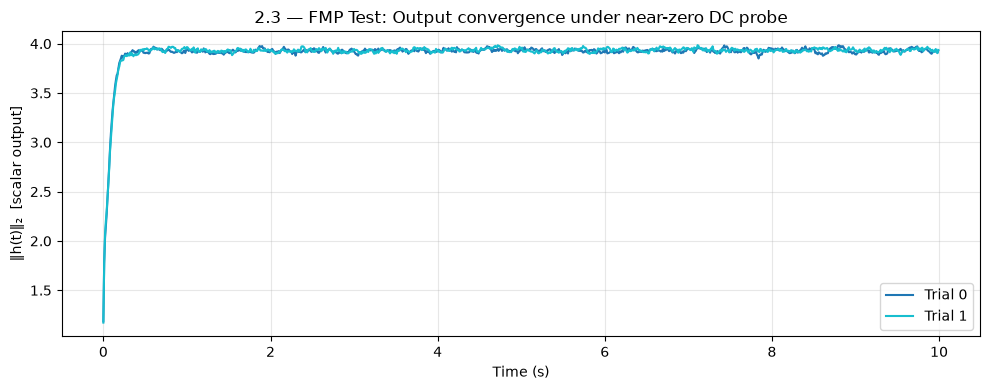

Observational orthogonality (FMP trial): 0.0053
FMP holds if all trial outputs converge to the same trajectory under u_B.


In [7]:
# ── 2.3 FMP Test ────────────────────────────────────────
# Generate N_TRIALS distinct settling inputs u_A^(i) — different random phases

fmp_outputs = []   # list of h_scalar arrays, one per trial
fmp_H_vecs  = []   # list of H arrays (full vector), one per trial

u_B = dc_near_zero(duration=PROBE_DURATION, fs=FS)  # near-zero DC probe

for trial_i in range(N_TRIALS):
    u_A = make_settle_input(trial_i, rng_offset=100)

    # --- Data collection: settle to distinct initial condition, then probe ---
    if DUT_MODEL == "hardware":
        H_probe = load_hardware_output(f"section2_fmp_trial_{trial_i:02d}.csv")
    else:
        dut.reset()
        dut.run(to_input_seq(u_A))   # drive to x_A^(i); discard output
        H_probe = dut.run(to_input_seq(u_B))   # shape (T_probe, N_h) — full electrode vector
        save_hardware_demo(f"section2_fmp_trial_{trial_i:02d}.csv", H_probe)
    h_scalar_probe = np.linalg.norm(H_probe, axis=1)   # shape (T_probe,) scalar

    fmp_outputs.append(h_scalar_probe)
    fmp_H_vecs.append(H_probe)

# ── Plot FMP: all trials overlaid ───────────────────────
t_probe = np.arange(len(u_B)) * DT
fig, ax = plt.subplots(figsize=(10, 4))
colors = plt.cm.tab10(np.linspace(0, 1, N_TRIALS))
for i, h_sc in enumerate(fmp_outputs):
    ax.plot(t_probe, h_sc, color=colors[i], lw=1.5, label=f"Trial {i}")

ax.set_xlabel("Time (s)")
ax.set_ylabel("‖h(t)‖₂  [scalar output]")
ax.set_title("2.3 — FMP Test: Output convergence under near-zero DC probe")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Orthogonality (use last trial's vector output as representative)
ortho_fmp = observational_orthogonality(fmp_H_vecs[-1])
print(f"Observational orthogonality (FMP trial): {ortho_fmp:.4f}")
print("FMP holds if all trial outputs converge to the same trajectory under u_B.")

### ESP Experiment

The same DUT is driven to distinct initial conditions with u_A^(i), then
switched to a common input u_C (different frequencies and mean amplitude from
u_A). Convergence under u_C demonstrates ESP: the input, not the initial
condition, determines the output trajectory. Compare with the FMP experiment
above — there, convergence occurred under near-zero input (intrinsic decay);
here, convergence is actively driven by the shared input signal.

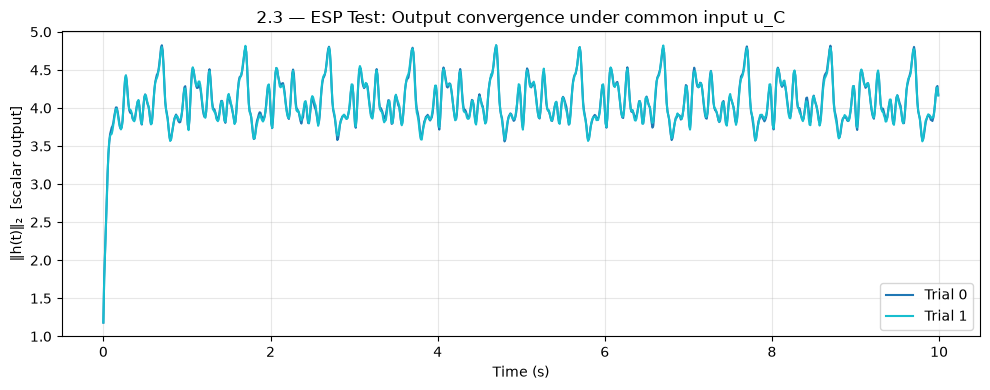

Observational orthogonality (ESP trial): 0.3300
ESP holds if all trial outputs are visually indistinguishable under u_C.


In [8]:
# ── 2.3 ESP Test ────────────────────────────────────────
# After settling with u_A^(i), swap to u_C and observe convergence.

# u_C: different from u_A — use different frequencies and mean amplitude
t_C = np.arange(int(ESP_SWAP_DURATION * FS)) * DT
u_C = V_SAFE * 0.4 * (
    np.sin(2*np.pi*2*t_C) +
    np.sin(2*np.pi*5*t_C) +
    np.sin(2*np.pi*9*t_C)
)
u_C = prepare_input(u_C, V_SAFE * 0.4, DUT_MODEL)

esp_outputs = []
esp_H_vecs  = []

for trial_i in range(N_TRIALS):
    u_A = make_settle_input(trial_i, rng_offset=200)

    # --- Data collection: settle to distinct initial condition, then probe ---
    if DUT_MODEL == "hardware":
        H_esp = load_hardware_output(f"section2_esp_trial_{trial_i:02d}.csv")
    else:
        dut.reset()
        dut.run(to_input_seq(u_A))   # establish distinct initial condition
        H_esp = dut.run(to_input_seq(u_C))   # shape (T_esp, N_h) — full vector
        save_hardware_demo(f"section2_esp_trial_{trial_i:02d}.csv", H_esp)
    h_scalar_esp = np.linalg.norm(H_esp, axis=1)   # scalar output

    esp_outputs.append(h_scalar_esp)
    esp_H_vecs.append(H_esp)

# ── Plot ESP: all trials overlaid ───────────────────────
t_esp = np.arange(len(u_C)) * DT
fig, ax = plt.subplots(figsize=(10, 4))
for i, h_sc in enumerate(esp_outputs):
    ax.plot(t_esp, h_sc, color=colors[i], lw=1.5, label=f"Trial {i}")

ax.set_xlabel("Time (s)")
ax.set_ylabel("‖h(t)‖₂  [scalar output]")
ax.set_title("2.3 — ESP Test: Output convergence under common input u_C")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

ortho_esp = observational_orthogonality(esp_H_vecs[-1])
print(f"Observational orthogonality (ESP trial): {ortho_esp:.4f}")
print("ESP holds if all trial outputs are visually indistinguishable under u_C.")

## 2.4 Separation Property (SP)

A Poisson spike train template u⁽⁰⁾ is generated. A variant u⁽¹⁾ is created by
delaying a single spike at t_spike by t_delay. Both are run through the DUT from
the same initial condition. The L2 norm of the difference between outputs is plotted
over time as the running mean d̄(t) and standard deviation σ(t).

SP holds when d̄(t) remains nonzero after the displaced spike with σ(t) small
relative to d̄(t) — indicating consistent, stable separation.

**I/O convention for this test:**
- u(t): scalar spike train input, shape (T,). Value is amplitude at spike times, 0 elsewhere.
- h(t): scalar output = ‖h‖₂ per trial, shape (T,).
- d(t) = |h⁽⁰⁾(t) − h⁽¹⁾(t)|  (scalar difference, shape (T,))
- Orthogonality: computed from full vector output H of one trial.

In simulation, both trials are driven to approximately the same starting state via
an independent sine washout before each trial, rather than by saving and restoring
internal DUT state — a simulation-only shortcut with no hardware equivalent. The
two post-washout states will not be bit-identical (especially with process noise);
the ESP guarantees they converge closely enough for this test. For hardware
recording instructions, see `00_hardware_signals.ipynb`.

run_until_settled: max_samples reached before settling criterion met (eps=0.0001). Proceeding with unsettled state. Consider increasing max_samples or adjusting input.


run_until_settled: max_samples reached before settling criterion met (eps=0.0001). Proceeding with unsettled state. Consider increasing max_samples or adjusting input.


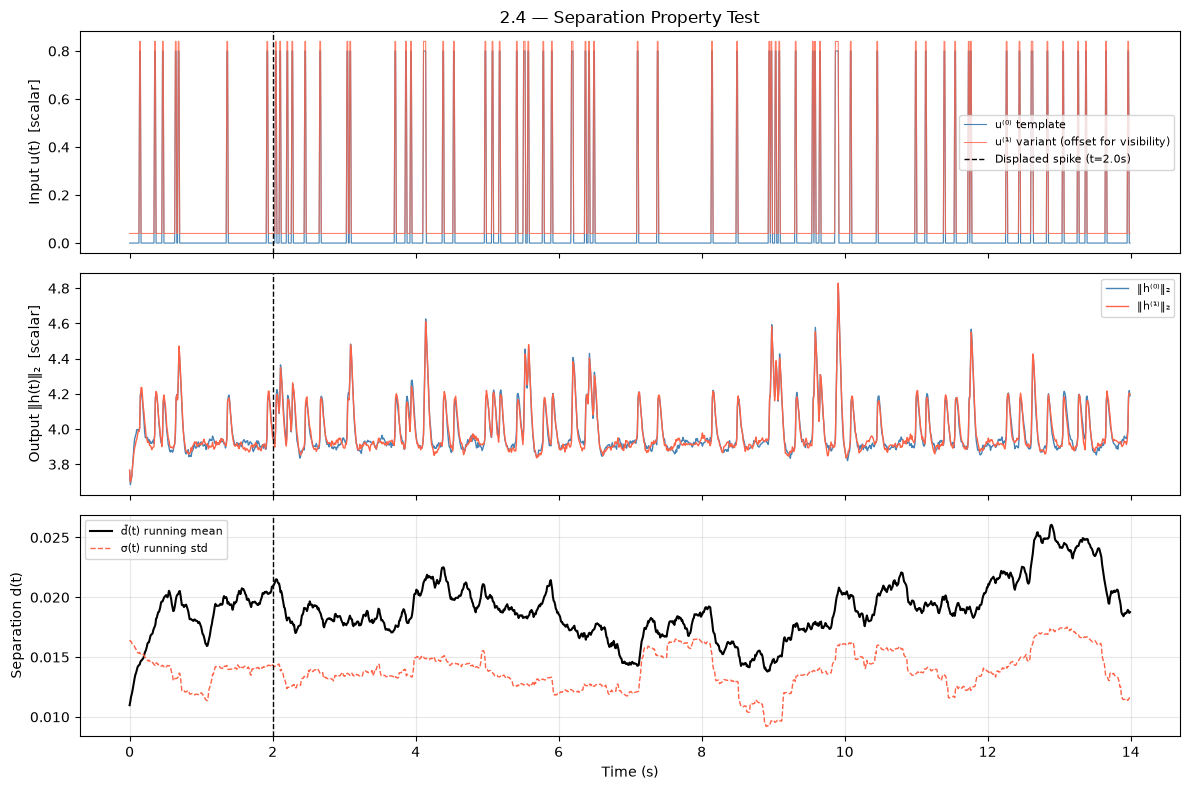

Observational orthogonality (SP test, trial 0): 0.0954
Post-spike mean separation d̄:  0.0190
Post-spike mean σ(t):           0.0139
σ/d̄ ratio (lower is better):   0.7298
SP holds when d̄ > 0 and σ/d̄ is small.


In [9]:
# ── 2.4 Separation Property Test ────────────────────────

# Generate template spike train u^(0)
u_template = poisson_spike_train(
    duration=SPIKE_DURATION,
    rate_hz=POISSON_RATE_HZ,
    amplitude=V_SAFE,
    pulse_width_samples=PULSE_WIDTH,
    fs=FS,
    seed=SEED_SPIKES
)

# Create variant u^(1) with one spike delayed
u_variant = delayed_spike_train(
    u_template=u_template,
    spike_idx=SPIKE_IDX,
    delay_samples=DELAY_SAMPLES
)

# ── Sine washout: reach a common starting state without state snapshotting ──
# (simulation-only DUT state save/restore has no hardware equivalent and
# breaks for DUTs without a single state vector, e.g. Ag2S-NWN). Used only
# in simulation -- see run_sp_trial() below.

WASHOUT_FREQ = 5.0          # Hz
WASHOUT_AMP  = V_SAFE

t_washout = np.arange(0, 1.0, DT)   # 1-second template, looped by run_until_settled
u_washout = WASHOUT_AMP * np.sin(2 * np.pi * WASHOUT_FREQ * t_washout)
u_washout = prepare_input(u_washout, WASHOUT_AMP, DUT_MODEL)
u_washout_seq = u_washout.reshape(-1, 1)   # shape (T_template, 1) per BaseDUT convention


def run_sp_trial(dut, u_trial):
    """
    Reset DUT, run sine washout until settled, then run the trial sequence.
    Returns H: output history over the trial only, shape (T_trial, N_h).

    NOTE: do NOT call dut.run() here — it resets the DUT internally before
    stepping, which would wipe the settled state. Step manually instead.
    """
    dut.reset()
    run_until_settled(dut, u_washout_seq)   # DUT is now at settled state

    # Step through the trial sequence without resetting
    u_trial = np.asarray(u_trial)
    T_trial = u_trial.shape[0]
    H = None
    for t in range(T_trial):
        h = dut.step(u_trial[t])
        if H is None:
            H = np.empty((T_trial, h.shape[0]), dtype=h.dtype)
        H[t] = h
    return H


# --- Data collection: trial 0 (template) ---
if DUT_MODEL == "hardware":
    H0 = load_hardware_output("section2_sp_trial_00.csv")
else:
    H0 = run_sp_trial(dut, to_input_seq(u_template))   # shape (T_spike, N_h) — full electrode vector
    save_hardware_demo("section2_sp_trial_00.csv", H0)
h0_scalar = np.linalg.norm(H0, axis=1)   # scalar, shape (T_spike,)

# --- Data collection: trial 1 (variant, one spike delayed) ---
if DUT_MODEL == "hardware":
    H1 = load_hardware_output("section2_sp_trial_01.csv")
else:
    H1 = run_sp_trial(dut, to_input_seq(u_variant))   # shape (T_spike, N_h)
    save_hardware_demo("section2_sp_trial_01.csv", H1)
h1_scalar = np.linalg.norm(H1, axis=1)   # scalar

# ── Separation metric ────────────────────────────────────
# d(t) = |‖h⁽⁰⁾‖₂ − ‖h⁽¹⁾‖₂|, i.e. the scalar difference of the two trials'
# output norms — NOT ‖h⁽⁰⁾ − h⁽¹⁾‖₂ (norm of the vector difference). Both are
# valid scalar separation metrics; this one is simpler and matches the scalar
# I/O convention used throughout this notebook (h always reduced via ‖·‖₂
# before comparison).
d = np.abs(h0_scalar - h1_scalar)   # shape (T_spike,) scalar

# Running mean and std (window = 1 second)
window = FS
d_mean = np.convolve(d, np.ones(window)/window, mode='same')
d_std  = np.array([
    np.std(d[max(0, i-window//2):min(len(d), i+window//2)])
    for i in range(len(d))
])

# ── Plot ──────────────────────────────────────────────────
t_sp = np.arange(len(u_template)) * DT
t_spike_sec = SPIKE_IDX * DT

# Trim the last `window` samples -- np.convolve's 'same' mode introduces a
# boundary artifact there (d_mean collapses toward zero at the very end of
# the series), which is not a real feature of the separation trajectory.
trim = window
t_plot   = t_sp[:-trim]
d_plot   = d[:-trim]
dm_plot  = d_mean[:-trim]
ds_plot  = d_std[:-trim]
u_template_plot = u_template[:-trim]
u_variant_plot  = u_variant[:-trim]
h0_scalar_plot  = h0_scalar[:-trim]
h1_scalar_plot  = h1_scalar[:-trim]

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

# Row 1: spike trains
axes[0].plot(t_plot, u_template_plot, color='steelblue', lw=0.8, label='u⁽⁰⁾ template')
axes[0].plot(t_plot, u_variant_plot + V_SAFE*0.05,  color='tomato',    lw=0.8,
             label='u⁽¹⁾ variant (offset for visibility)', alpha=0.8)
axes[0].axvline(t_spike_sec, color='k', ls='--', lw=1, label=f'Displaced spike (t={t_spike_sec:.1f}s)')
axes[0].set_ylabel("Input u(t)  [scalar]")
axes[0].set_title("2.4 — Separation Property Test")
axes[0].legend(fontsize=8)

# Row 2: outputs
axes[1].plot(t_plot, h0_scalar_plot, color='steelblue', lw=1, label='‖h⁽⁰⁾‖₂')
axes[1].plot(t_plot, h1_scalar_plot, color='tomato',    lw=1, label='‖h⁽¹⁾‖₂')
axes[1].axvline(t_spike_sec, color='k', ls='--', lw=1)
axes[1].set_ylabel("Output ‖h(t)‖₂  [scalar]")
axes[1].legend(fontsize=8)

# Row 3: separation d̄(t) and σ(t)
axes[2].plot(t_plot, dm_plot, color='k',      lw=1.5, label='d̄(t) running mean')
axes[2].plot(t_plot, ds_plot, color='tomato', lw=1.0, label='σ(t) running std', ls='--')
axes[2].axvline(t_spike_sec, color='k', ls='--', lw=1)
axes[2].set_xlabel("Time (s)")
axes[2].set_ylabel("Separation d(t)")
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Orthogonality (from trial 0 full vector output)
ortho_sp = observational_orthogonality(H0)
print(f"Observational orthogonality (SP test, trial 0): {ortho_sp:.4f}")

# Post-spike mean separation (mean d̄ after displaced spike time)
post_spike_mask = t_plot > t_spike_sec
d_post_mean = float(dm_plot[post_spike_mask].mean())
d_post_std  = float(ds_plot[post_spike_mask].mean())
print(f"Post-spike mean separation d̄:  {d_post_mean:.4f}")
print(f"Post-spike mean σ(t):           {d_post_std:.4f}")
print(f"σ/d̄ ratio (lower is better):   {d_post_std/(d_post_mean+1e-12):.4f}")
print("SP holds when d̄ > 0 and σ/d̄ is small.")

In [10]:
# ── Section 2 Results Summary ──────────────────────────

results_s2 = {
    "ortho_fingerprint_mean":   ortho_fp_mean,
    "ortho_fmp":                float(ortho_fmp),
    "ortho_esp":                float(ortho_esp),
    "ortho_sp":                 float(ortho_sp),
    "sp_post_spike_d_mean":     d_post_mean,
    "sp_post_spike_sigma_mean": d_post_std,
    "sp_sigma_over_d":          float(d_post_std / (d_post_mean + 1e-12)),
    "test_params": {
        "N_AMP_STEPS_FP":    N_AMP_STEPS_FP,
        "POISSON_RATE_HZ":   POISSON_RATE_HZ,
        "SPIKE_IDX":         SPIKE_IDX,
        "DELAY_SAMPLES":     DELAY_SAMPLES,
        "PULSE_WIDTH":       PULSE_WIDTH,
    }
}

with open(os.path.join(RESULTS_DIR, "section2_results.json"), "w") as f:
    json.dump(results_s2, f, indent=2)

print("=" * 50)
print("SECTION 2 RESULTS SUMMARY")
print("=" * 50)
print(f"  Ortho (fingerprint sweep): {ortho_fp_mean:.4f}")
print(f"  Ortho (FMP test):          {ortho_fmp:.4f}")
print(f"  Ortho (ESP test):          {ortho_esp:.4f}")
print(f"  Ortho (SP test):           {ortho_sp:.4f}")
print(f"  SP post-spike d̄:           {d_post_mean:.4f}")
print(f"  SP σ/d̄:                    {d_post_std/(d_post_mean+1e-12):.4f}")
print(f"\nResults saved to {RESULTS_DIR}section2_results.json")
print("Proceed to Section 3 for quantitative system characterization.")

SECTION 2 RESULTS SUMMARY
  Ortho (fingerprint sweep): 0.2824
  Ortho (FMP test):          0.0053
  Ortho (ESP test):          0.3300
  Ortho (SP test):           0.0954
  SP post-spike d̄:           0.0190
  SP σ/d̄:                    0.7298

Results saved to results/section2_results.json
Proceed to Section 3 for quantitative system characterization.
